# Notebook 04 — Piano Reaction Analysis
Analyses response time, hit/miss/timeout patterns, and key transition distances.

| Audience | What they get |
|---|---|
| **User / Patient** | Your reaction speed and accuracy scores, session by session |
| **Doctor / Clinician** | Finger reflex speed, timeout rate, and which keys cause failures |
| **App maker** | Which key distances produce more errors — tune level design |


In [1]:
DATA_DIR       = '.'
OUT_DIR        = 'outputs'
GROUP_LABEL    = 'Group A'
MIN_KEYPRESSES = 3
import os, json, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# ── Make sure output folder exists BEFORE anything tries to write to it ──
os.makedirs(OUT_DIR, exist_ok=True)

sys.path.insert(0, os.path.dirname(os.path.abspath('hci_utils.py')))
from hci_utils import (load_board_tries, load_bd_sessions, load_piano_sessions,
                        load_piano_movements, compare_groups, save_fig,
                        SHAPE_ORDER, HAND_COLORS, GROUP_COLORS)

sessions, keypresses = load_piano_sessions(DATA_DIR)
movements = load_piano_movements(DATA_DIR)
valid = sessions[sessions['is_valid']].copy().reset_index(drop=True)
valid['session_num'] = range(1, len(valid) + 1)
print(f'Total sessions: {len(sessions)}  Valid: {len(valid)}  '
      f'Abandoned: {len(sessions)-len(valid)}')
print(valid[['session_id','sessionScore','hits','misses','timeouts','hit_rate','avg_rt']].to_string())


Total sessions: 5  Valid: 4  Abandoned: 1
                 session_id  sessionScore  hits  misses  timeouts  hit_rate    avg_rt
0  6a13e0e5f7784aa3918a34a9            85     9       1         1  0.818182  0.980000
1  6a13e142f7784aa3918a34ea           115    12       6         1  0.631579  0.961538
2  6a13e32844d197e8daee162d            65     7       0         1  0.875000  1.000000
3  6a14219e63a8dbfaa4a19f50            20     3       0         2  0.600000  0.500000


## Fig 04a — Session scores over time

Saved -> outputs/fig04a_piano_session_scores.png


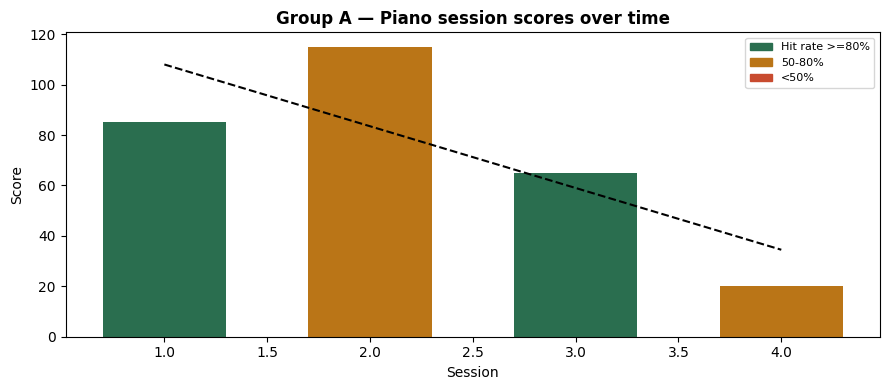


=== USER FEEDBACK ===
Best session: S2 with score 115
Average score: 71.2
Score trend: -declining (slope=-24.5 pts/session)

=== CLINICIAN SIGNAL ===
Hit rate range: 60.0% - 87.5%
Timeout rate across all sessions: 11.6%
High timeout rate = finger speed below the set threshold — consider adjusting timeout limits.


In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2a6e4f' if r >= 0.8 else '#ba7517' if r >= 0.5 else '#c84b2f'
          for r in valid['hit_rate'].fillna(0)]
ax.bar(valid['session_num'], valid['sessionScore'], color=colors, width=0.6)
if len(valid) >= 2:
    from scipy import stats as sp
    sl, ic, rv, pv, _ = sp.linregress(valid['session_num'], valid['sessionScore'])
    xl = np.array([1, len(valid)])
    ax.plot(xl, ic + sl * xl, '--', color='black', lw=1.5,
            label=f'Trend (r²={rv**2:.2f}, p={pv:.2f})')
ax.set_xlabel('Session')
ax.set_ylabel('Score')
ax.set_title(GROUP_LABEL + ' — Piano session scores over time', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2a6e4f', label='Hit rate >=80%'),
    mpatches.Patch(color='#ba7517', label='50-80%'),
    mpatches.Patch(color='#c84b2f', label='<50%'),
], fontsize=8)
plt.tight_layout()
save_fig(fig, 'fig04a_piano_session_scores.png', OUT_DIR)
plt.show()

print('\n=== USER FEEDBACK ===')
best_s = valid.loc[valid['sessionScore'].idxmax()]
print(f"Best session: S{int(best_s['session_num'])} with score {int(best_s['sessionScore'])}")
avg_score = valid['sessionScore'].mean()
print(f'Average score: {avg_score:.1f}')
if len(valid) >= 2:
    print(f'Score trend: {"+improving" if sl > 0 else "-declining"} '
          f'(slope={sl:.1f} pts/session)')

print('\n=== CLINICIAN SIGNAL ===')
print(f'Hit rate range: {valid["hit_rate"].min()*100:.1f}% - {valid["hit_rate"].max()*100:.1f}%')
to_rate = valid['timeouts'].sum() / valid['total_keys'].sum() * 100
print(f'Timeout rate across all sessions: {to_rate:.1f}%')
print('High timeout rate = finger speed below the set threshold — '
      'consider adjusting timeout limits.')


## Fig 04b — Hit / Miss / Timeout stacked bar

Saved -> outputs/fig04b_hit_miss_timeout.png


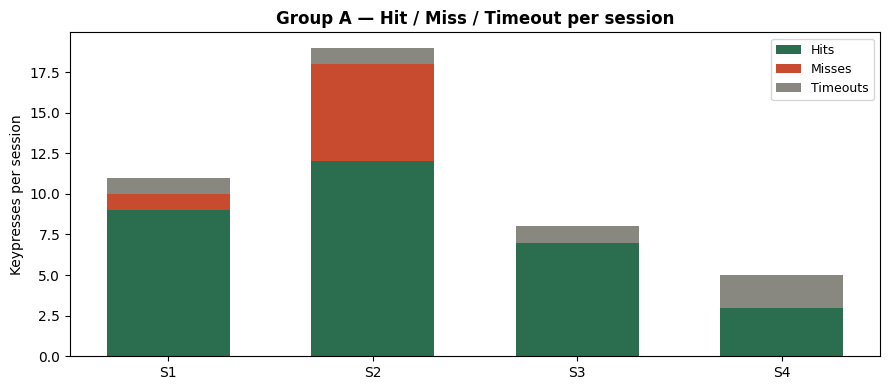


=== CLINICIAN SIGNAL ===
Misses = wrong key pressed (coordination error)
Timeouts = correct key not pressed in time (speed deficit)
Tracking which type dominates guides whether therapy targets accuracy or speed.


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
idx = range(len(valid))
ax.bar(idx, valid['hits'],     label='Hits',     color='#2a6e4f', width=0.6)
ax.bar(idx, valid['misses'],   label='Misses',   color='#c84b2f', width=0.6,
       bottom=valid['hits'])
ax.bar(idx, valid['timeouts'], label='Timeouts', color='#888780', width=0.6,
       bottom=valid['hits'] + valid['misses'])
ax.set_xticks(idx)
ax.set_xticklabels([f'S{i+1}' for i in idx])
ax.set_ylabel('Keypresses per session')
ax.set_title(GROUP_LABEL + ' — Hit / Miss / Timeout per session', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'fig04b_hit_miss_timeout.png', OUT_DIR)
plt.show()

print('\n=== CLINICIAN SIGNAL ===')
print('Misses = wrong key pressed (coordination error)')
print('Timeouts = correct key not pressed in time (speed deficit)')
print('Tracking which type dominates guides whether therapy targets accuracy or speed.')


## Fig 04c — Response time histogram

Saved -> outputs/fig04c_response_time_histogram.png


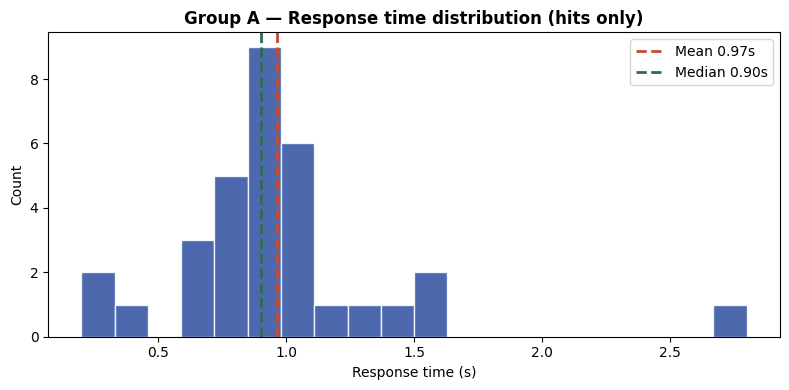


=== CLINICIAN SIGNAL ===
Mean RT: 0.966s  |  Std: 0.451s
95th percentile: 1.545s
High std = inconsistent reflex speed. Track mean RT over sessions — decreasing mean = measurable speed improvement.

=== USER FEEDBACK ===
Your average reaction time: 0.97s
Aim to reduce this over sessions through consistent practice.


In [4]:
valid_rt = keypresses[
    (keypresses['responsetime'] > 0) & (keypresses['correct'] == 1)
]['responsetime']

if valid_rt.empty:
    print('No valid response time data found.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(valid_rt, bins=20, color='#2c4fa0', edgecolor='white', alpha=0.85)
    ax.axvline(valid_rt.mean(),   color='#c84b2f', lw=2, ls='--',
               label=f'Mean {valid_rt.mean():.2f}s')
    ax.axvline(valid_rt.median(), color='#2a6e4f', lw=2, ls='--',
               label=f'Median {valid_rt.median():.2f}s')
    ax.set_xlabel('Response time (s)')
    ax.set_ylabel('Count')
    ax.set_title(GROUP_LABEL + ' — Response time distribution (hits only)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    save_fig(fig, 'fig04c_response_time_histogram.png', OUT_DIR)
    plt.show()

    print('\n=== CLINICIAN SIGNAL ===')
    print(f'Mean RT: {valid_rt.mean():.3f}s  |  Std: {valid_rt.std():.3f}s')
    print(f'95th percentile: {valid_rt.quantile(0.95):.3f}s')
    print('High std = inconsistent reflex speed. Track mean RT over sessions — '
          'decreasing mean = measurable speed improvement.')
    print('\n=== USER FEEDBACK ===')
    print(f'Your average reaction time: {valid_rt.mean():.2f}s')
    print('Aim to reduce this over sessions through consistent practice.')


## Fig 04d — Key transition distance vs frequency

Saved -> outputs/fig04d_distance_distribution.png


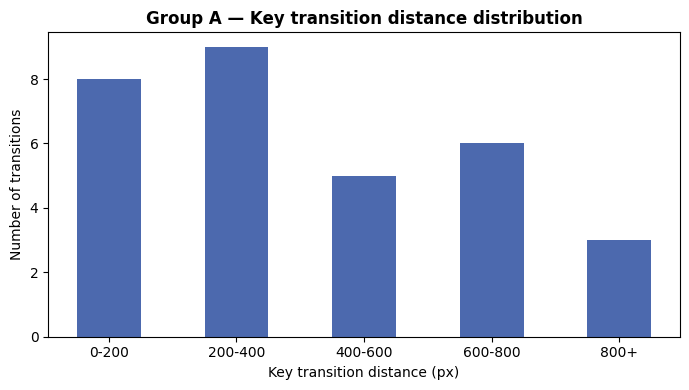


=== APP-MAKER SIGNAL ===
Rare long-distance transitions (800+px) = high motor demand.
If error rates are high for those, reduce their spawn rate at lower difficulty levels.


In [5]:
if movements.empty:
    print('No movement data found.')
else:
    bins   = [0, 200, 400, 600, 800, 1200]
    labels = ['0-200', '200-400', '400-600', '600-800', '800+']
    movements['dist_bucket'] = pd.cut(movements['distance'], bins=bins, labels=labels)
    mov_agg = movements.groupby('dist_bucket', observed=True).agg(
        count=('distance','count')).reset_index()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(mov_agg['dist_bucket'].astype(str), mov_agg['count'],
           color='#2c4fa0', alpha=0.85, width=0.5)
    ax.set_xlabel('Key transition distance (px)')
    ax.set_ylabel('Number of transitions')
    ax.set_title(GROUP_LABEL + ' — Key transition distance distribution', fontweight='bold')
    plt.tight_layout()
    save_fig(fig, 'fig04d_distance_distribution.png', OUT_DIR)
    plt.show()

    print('\n=== APP-MAKER SIGNAL ===')
    print('Rare long-distance transitions (800+px) = high motor demand.')
    print('If error rates are high for those, reduce their spawn rate at lower difficulty levels.')


## Fig 04e — Key transition heatmap

Saved -> outputs/fig04e_key_transition_heatmap.png


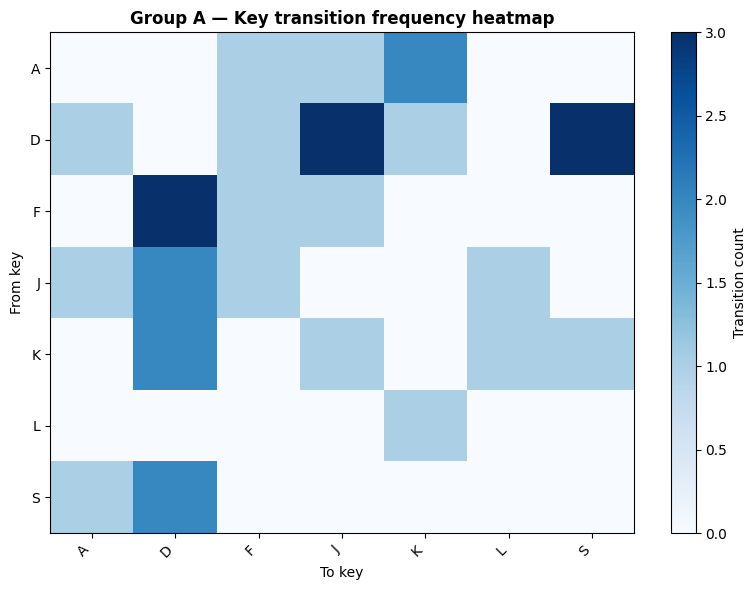


=== CLINICIAN SIGNAL ===
High-frequency transitions the patient struggles on = targeted finger exercises.

=== APP-MAKER SIGNAL ===
Blank rows/columns = keys never reached. Check if level design is balanced.
piano_session_summary.csv saved


In [6]:
if not movements.empty:
    pivot = movements.groupby(['fromKey','toKey']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    plt.colorbar(im, ax=ax, label='Transition count')
    ax.set_xlabel('To key')
    ax.set_ylabel('From key')
    ax.set_title(GROUP_LABEL + ' — Key transition frequency heatmap', fontweight='bold')
    plt.tight_layout()
    save_fig(fig, 'fig04e_key_transition_heatmap.png', OUT_DIR)
    plt.show()

    print('\n=== CLINICIAN SIGNAL ===')
    print('High-frequency transitions the patient struggles on = targeted finger exercises.')
    print('\n=== APP-MAKER SIGNAL ===')
    print('Blank rows/columns = keys never reached. Check if level design is balanced.')

# Save summary
valid.to_csv(os.path.join(OUT_DIR, 'piano_session_summary.csv'), index=False)
print('piano_session_summary.csv saved')
